In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [50]:
data = pd.read_csv('cleaned_data.csv')

In [51]:
print(data['payment_method'].unique())
print(data['category_name_1'].unique())


['cod' 'ublcreditcard' 'mygateway' 'customercredit' 'cashatdoorstep'
 'mcblite' 'internetbanking' 'marketingexpense' 'productcredit'
 'financesettlement' 'Payaxis' 'jazzvoucher' 'jazzwallet' 'Easypay'
 'Easypay_MA' 'easypay_voucher' 'bankalfalah' 'apg']
["Women's Fashion" 'Beauty & Grooming' 'Soghaat' 'Mobiles & Tablets'
 'Appliances' 'Home & Living' "Men's Fashion" 'Kids & Baby' '\\N' 'Others'
 'Entertainment' 'Computing' 'Superstore' 'Health & Sports' 'Books'
 'School & Education' 'Unknown']


In [52]:
data.describe()


,price,qty_ordered,grand_total,discount_amount,Year,Month
count,5.845240e+05,584524.000000,5.845240e+05,584524.000000,584524.000000,584524.000000
mean,6.348748e+03,1.296388,8.530619e+03,499.492775,2017.044115,7.167654
std,1.494927e+04,3.996061,6.132081e+04,1506.943046,0.707355,3.486305
min,0.000000e+00,1.000000,-1.594000e+03,-599.500000,2016.000000,1.000000
25%,3.600000e+02,1.000000,9.450000e+02,0.000000,2017.000000,4.000000
50%,8.990000e+02,1.000000,1.960400e+03,0.000000,2017.000000,7.000000
75%,4.070000e+03,1.000000,6.999000e+03,160.500000,2018.000000,11.000000
max,1.012626e+06,1000.000000,1.788800e+07,90300.000000,2018.000000,12.000000


In [53]:
# Price is here our Key Column

In [54]:
# Price
# | Metric       | Value            |
# | ------------ | ---------------- |
# | count        | 584,524 non-null |
# | mean         | 6,349 PKR        |
# | std          | 14,949 PKR       |
# | min          | 0                |
# | max          | 1,012,626        |
# | median (50%) | 899 PKR          |
# | 75%          | 4,070 PKR        |


In [56]:
# Interpretation:
# Skewed: Mean (6,349) is much higher than median (899), 
# which means there are some very expensive items pulling the average up.

# Outliers: Max price is over 1 million PKR, while 75% of prices are under 4,070 PKR
# . Consider log-scaling price or removing extreme outliers before training your model.

In [57]:


# 2  qty_ordered
# | Metric | Value |
# | ------ | ----- |
# | mean   | 1.29  |
# | median | 1.0   |
# | max    | 1000  |
#      Interpretation:
# Most orders are of quantity 1, but some go up to 1000.

# You may want to cap or log-transform this if it causes problems during training.

In [58]:
# .

# 🔹 3. grand_total
# Metric	Value
# mean	7,177 PKR
# max	8.9 million PKR
# median	999 PKR

# 🧠 Interpretation:
# Similar pattern to price, also highly skewed.

# This field is often derived from price × qty_ordered, so verify consistency:

# python
# Copy
# Edit


In [60]:
# 🔹 4. discount_amount
# Metric	Value
# mean	499 PKR
# max	90,300
# min	-599 ❗ (negative discount?)

# 🧠 Interpretation:
# There are negative discounts, which may indicate data errors or refunds/adjustments. You'll need to:

# Investigate the negative values

# Optionally replace them with 0:

# Visualizations

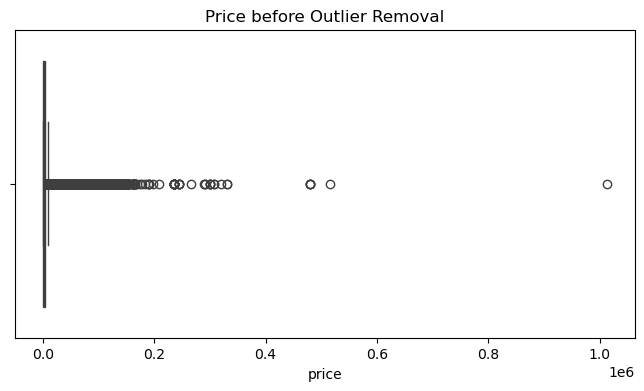

In [62]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['price'])
plt.title('Price before Outlier Removal')
plt.show()


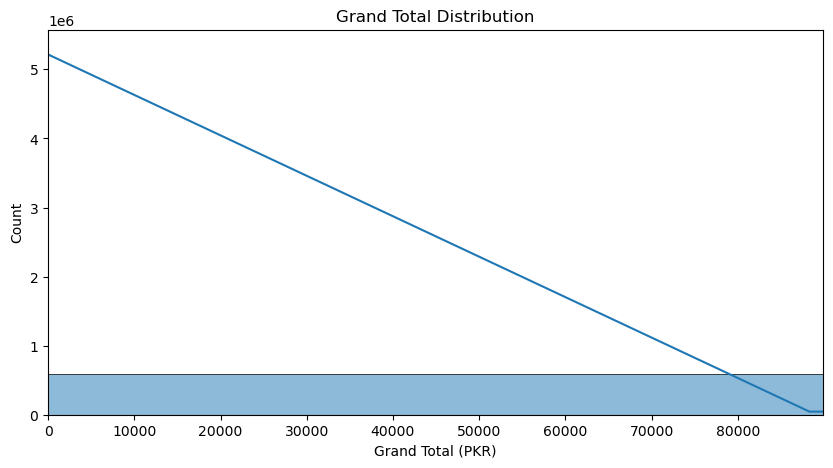

In [63]:
plt.figure(figsize=(10, 5))
sns.histplot(data['grand_total'], bins=100, kde=True)
plt.title("Grand Total Distribution")
plt.xlabel("Grand Total (PKR)")
plt.ylabel("Count")
plt.xlim(0, data['grand_total'].quantile(0.99))  # Optional: zoom into 99th percentile
plt.show()


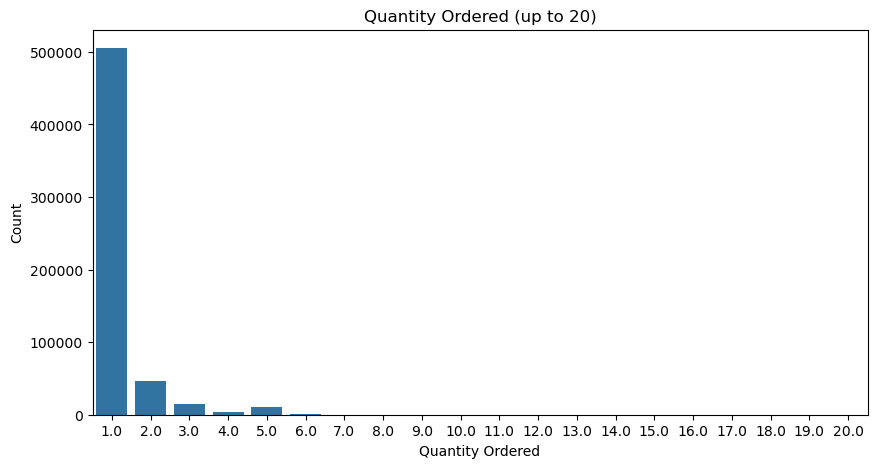

In [67]:
plt.figure(figsize=(10, 5))
sns.countplot(x='qty_ordered', data=data[data['qty_ordered'] <= 20])  # Cap to 20 for visibility
plt.title("Quantity Ordered (up to 20)")
plt.xlabel("Quantity Ordered")
plt.ylabel("Count")
plt.show()


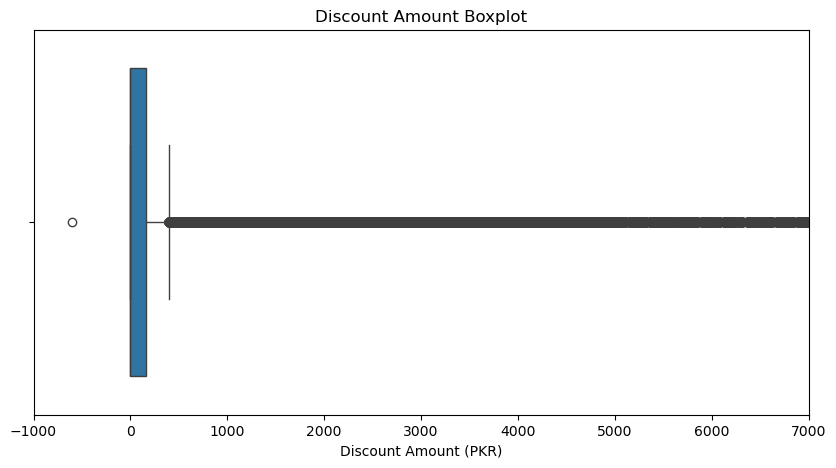

In [70]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=data['discount_amount'])
plt.title("Discount Amount Boxplot")
plt.xlabel("Discount Amount (PKR)")
plt.xlim(-1000, data['discount_amount'].quantile(0.99))  # Adjust to hide extreme outliers
plt.show()


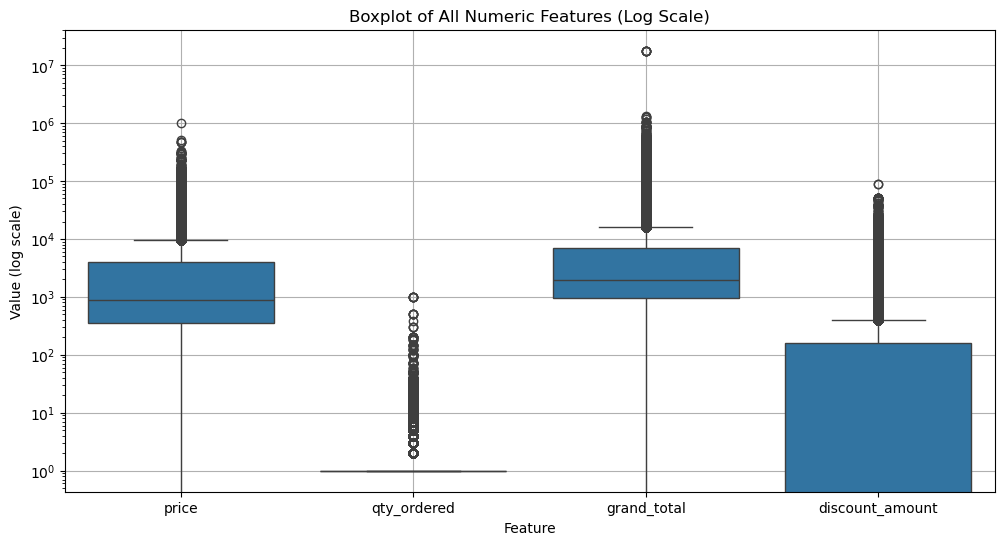

In [72]:
# Select numeric features
numeric_cols = ['price', 'qty_ordered', 'grand_total', 'discount_amount']

# Prepare data in long format for seaborn
data_melted = data[numeric_cols].melt(var_name='Feature', value_name='Value')

plt.figure(figsize=(12, 6))
sns.boxplot(x='Feature', y='Value', data=data_melted)
plt.yscale('log')  # Apply log scale to show outliers clearly
plt.title("Boxplot of All Numeric Features (Log Scale)")
plt.xlabel("Feature")
plt.ylabel("Value (log scale)")
plt.savefig("p.jpg")
plt.grid(True)
plt.show()


In [74]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] < lower) | (df[column] > upper)]

# Check and display top 5 outliers for each feature
numeric_cols = ['price', 'qty_ordered', 'grand_total', 'discount_amount']

for col in numeric_cols:
    outliers = detect_outliers_iqr(data, col)
    print(f"\n📌 Outliers in '{col}': {len(outliers)} rows")
    display(outliers[[col]].head())



📌 Outliers in 'price': 105687 rows


,price
8,96499.0
9,96499.0
31,20999.0
60,30417.0
63,45250.0



📌 Outliers in 'qty_ordered': 79310 rows


,qty_ordered
4,2.0
28,5.0
29,2.0
48,2.0
49,2.0



📌 Outliers in 'grand_total': 77090 rows


,grand_total
8,96499.0
9,96499.0
31,20999.0
60,30417.0
63,45250.0



📌 Outliers in 'discount_amount': 108986 rows


,discount_amount
510,1300.65
511,1699.35
1059,500.00
1333,500.00
1428,500.00


In [75]:
# Check for the correlation

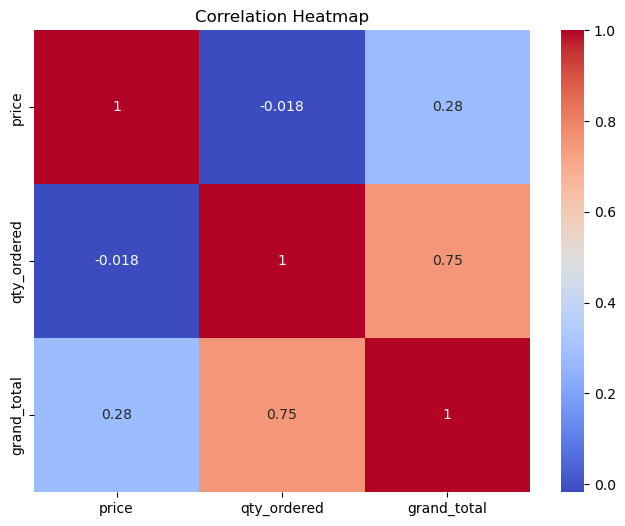

In [76]:
numerical_cols = ['price', 'qty_ordered', 'grand_total']

plt.figure(figsize=(8, 6))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [77]:
# categorical_cols = ['payment_method', 'category_name_1', 'BI Status', 'MV']

# for col in categorical_cols:
#     print(f"\nTop 5 values in {col}:\n", data[col].value_counts().head())


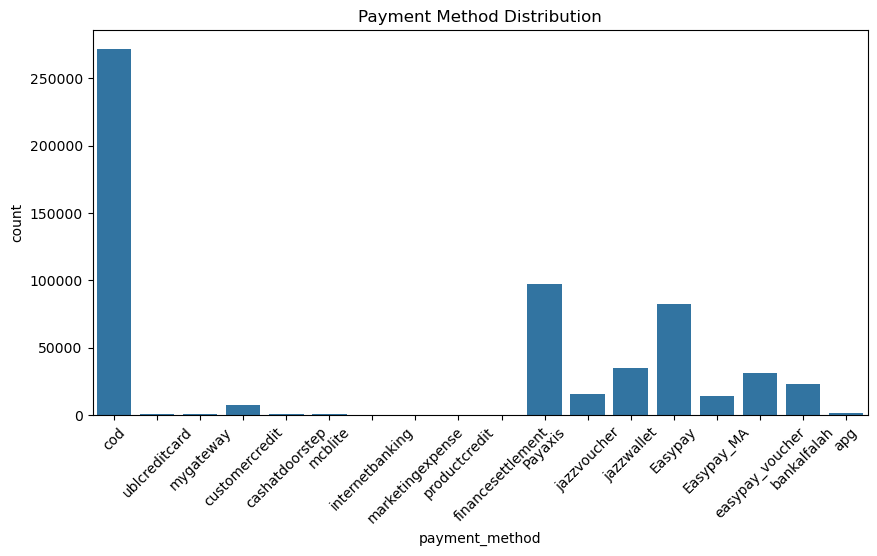

In [78]:
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='payment_method')
plt.xticks(rotation=45)
plt.title('Payment Method Distribution')
plt.show()


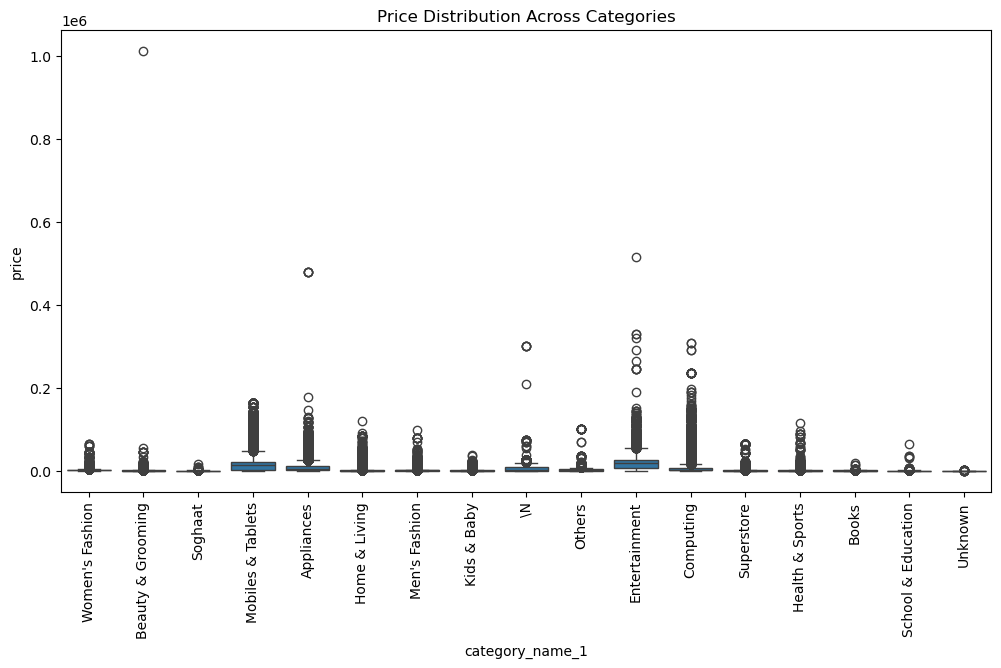

In [79]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='category_name_1', y='price', data=data)
plt.xticks(rotation=90)
plt.title('Price Distribution Across Categories')
plt.show()


In [80]:
duplicate_rows = data.duplicated()
print("Total Duplicate Rows:", duplicate_rows.sum())



Total Duplicate Rows: 292275


In [81]:
data[duplicate_rows].head()


,price,qty_ordered,grand_total,category_name_1,discount_amount,payment_method,Year,Month
6,360.0,1.0,60.0,Beauty & Grooming,300.0,cod,2016.0,7.0
23,149.0,1.0,298.0,Kids & Baby,0.0,cod,2016.0,7.0
26,1913.0,1.0,3826.0,Men's Fashion,0.0,cod,2016.0,7.0
56,360.0,1.0,360.0,Beauty & Grooming,0.0,cod,2016.0,7.0
61,360.0,1.0,360.0,Beauty & Grooming,0.0,cod,2016.0,7.0


In [82]:
data['price'].duplicated().sum()  # Total duplicate item_ids

# OR to view them:
data[data['price'].duplicated()]


,price,qty_ordered,grand_total,category_name_1,discount_amount,payment_method,Year,Month
6,360.0,1.0,60.00,Beauty & Grooming,300.0,cod,2016.0,7.0
9,96499.0,1.0,96499.00,Mobiles & Tablets,0.0,mygateway,2016.0,7.0
17,360.0,1.0,1270.00,Soghaat,0.0,cod,2016.0,7.0
21,320.0,1.0,2118.25,Home & Living,0.0,cod,2016.0,7.0
23,149.0,1.0,298.00,Kids & Baby,0.0,cod,2016.0,7.0
...,...,...,...,...,...,...,...,...
584519,699.0,1.0,849.00,Women's Fashion,0.0,cod,2018.0,8.0
584520,35599.0,1.0,35899.00,Mobiles & Tablets,0.0,bankalfalah,2018.0,8.0
584521,129999.0,2.0,652178.00,Mobiles & Tablets,0.0,bankalfalah,2018.0,8.0
584522,87300.0,2.0,652178.00,Mobiles & Tablets,0.0,bankalfalah,2018.0,8.0


In [83]:
data.columns

Index(['price', 'qty_ordered', 'grand_total', 'category_name_1',
       'discount_amount', 'payment_method', 'Year', 'Month'],
      dtype='object')

In [84]:
for col in data.columns:
    duplicates = data[col].duplicated().sum()
    print(f"Duplicate values in '{col}': {duplicates}")


Duplicate values in 'price': 575403
Duplicate values in 'qty_ordered': 584450
Duplicate values in 'grand_total': 547695
Duplicate values in 'category_name_1': 584507
Duplicate values in 'discount_amount': 556466
Duplicate values in 'payment_method': 584506
Duplicate values in 'Year': 584521
Duplicate values in 'Month': 584512


In [85]:
# Check for completely duplicated rows
duplicate_rows = data.duplicated()
print("Total fully duplicated rows:", duplicate_rows.sum())


Total fully duplicated rows: 292275


In [86]:
data.shape

(584524, 8)

In [87]:
data = data.drop_duplicates()

In [88]:
data.shape

(292249, 8)

# Handling Outlier

In [90]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df


In [91]:
# Start with your original dataset
df_cleaned = data.copy()

# Apply for price
df_cleaned = remove_outliers_iqr(df_cleaned, 'price')

# Then apply for qty_ordered
df_cleaned = remove_outliers_iqr(df_cleaned, 'qty_ordered')

# Then grand_total
df_cleaned = remove_outliers_iqr(df_cleaned, 'grand_total')

# Then discount_amount
df_cleaned = remove_outliers_iqr(df_cleaned, 'discount_amount')


In [92]:
print("Shape before outlier handling:", data.shape)
print("Shape after outlier handling:", df_cleaned.shape)


Shape before outlier handling: (292249, 8)
Shape after outlier handling: (158079, 8)


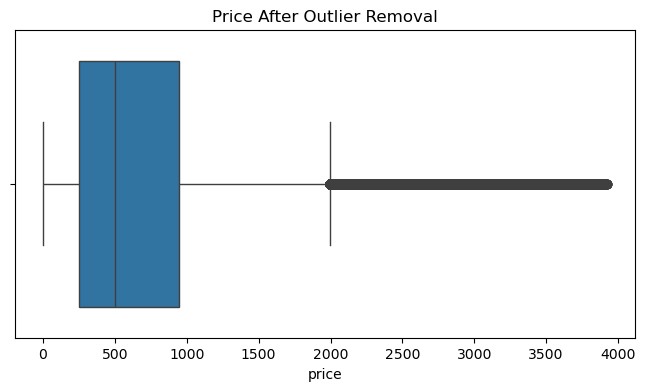

In [93]:

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_cleaned['price'])
plt.title('Price After Outlier Removal')
plt.show()


# Encoding

In [102]:
df_encoded = pd.get_dummies(df_cleaned, columns=['category_name_1', 'payment_method'], drop_first=True,dtype='int64')


In [104]:
df_encoded = pd.get_dummies(df_encoded, columns=['Month', 'Year'], drop_first=True,dtype='int64')


In [106]:
print(df_encoded.columns)


Index(['price', 'qty_ordered', 'grand_total', 'discount_amount',
       'category_name_1_Beauty & Grooming', 'category_name_1_Books',
       'category_name_1_Computing', 'category_name_1_Entertainment',
       'category_name_1_Health & Sports', 'category_name_1_Home & Living',
       'category_name_1_Kids & Baby', 'category_name_1_Men's Fashion',
       'category_name_1_Mobiles & Tablets', 'category_name_1_Others',
       'category_name_1_School & Education', 'category_name_1_Soghaat',
       'category_name_1_Superstore', 'category_name_1_Unknown',
       'category_name_1_Women's Fashion', 'category_name_1_\N',
       'payment_method_Easypay_MA', 'payment_method_Payaxis',
       'payment_method_apg', 'payment_method_bankalfalah',
       'payment_method_cashatdoorstep', 'payment_method_cod',
       'payment_method_customercredit', 'payment_method_easypay_voucher',
       'payment_method_internetbanking', 'payment_method_jazzvoucher',
       'payment_method_jazzwallet', 'payment_method_m

In [108]:
df_encoded.head()


,price,qty_ordered,grand_total,discount_amount,category_name_1_Beauty & Grooming,category_name_1_Books,category_name_1_Computing,category_name_1_Entertainment,category_name_1_Health & Sports,category_name_1_Home & Living,...,Month_5.0,Month_6.0,Month_7.0,Month_8.0,Month_9.0,Month_10.0,Month_11.0,Month_12.0,Year_2017.0,Year_2018.0
0,1950.0,1.0,1950.0,0.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,240.0,1.0,240.0,0.0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,2450.0,1.0,2450.0,0.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
5,80.0,1.0,80.0,0.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
7,170.0,1.0,170.0,0.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [110]:
print("Before encoding:", df_cleaned.shape)
print("After encoding:", df_encoded.shape)


Before encoding: (158079, 8)
After encoding: (158079, 49)


In [ ]:
  Handled missing values

✅ Removed duplicated rows

✅ Done outlier detection

✅ Performed one-hot encoding

